# **Set Up**

In [ ]:
!git clone https://github.com/Brian5998/smiles-gpt

Cloning into 'smiles-gpt'...
remote: Enumerating objects: 32, done.
remote: Total 32 (delta 0), reused 0 (delta 0), pack-reused 32
Unpacking objects: 100% (32/32), 61.46 MiB | 8.01 MiB/s, done.


In [ ]:
%cd smiles-gpt

/content/smiles-gpt


In [ ]:
!pwd

/content/smiles-gpt


In [ ]:
!pip install anaconda
!pip install conda-forge
!pip install python==3.8
!pip install pandas
!pip install rdkit
!pip install torchaudio
!pip install tokenizers
!pip install adapter-transformers
!pip install pytorch-lightning
!pip install bertviz
!pip install pytorch

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for anaconda: filename=anaconda-0.0.1.1-py3-none-any.whl size=1124 sha256=09d8084e4ecb947671cd3db6ad1ff96d300d9dbb9ec3e97e02a02016621ba74e
  Stored in directory: /root/.cache/pip/wheels/c2/f4/d5/04ee4841afe97419e952e4906651f4c55b39fb1038715b715e
Successfully built anaconda
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: Could not find a version that satisfies the requirement conda-forge (from versions: none)
ERROR: No matching distribution found for conda-forge
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: Could not find a version that satisfies the requirement python==3.8 (from versions: none)
ERROR: No matching distribution found for python==3.8
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev

In [ ]:
#When you get an error for get_cache import line, just go to the file source
#and remove that import line and rerun it because that import line is not neccessary

try:
    import smiles_gpt as gpt
except ImportError:
    import sys
    sys.path.extend([".."])  # Parent directory stores `smiles_gpt` package.
    import smiles_gpt as gpt

# **Model Training**

In [ ]:
# 10K subset of PubChem SMILES dataset - replaced with purchasable fragment input
filename = "/content/smiles-gpt/data/molgan_input.txt"
# Directory to serialize a tokenizer and model.
checkpoint = "/content/smiles-gpt/checkpoints/benchmark-5m/"
tokenizer_filename = f"{checkpoint}/tokenizer.json"

# Tokenizer, model, optimizer, scheduler, and trainer hyperparameters.
hyperparams = {"batch_size": 64, "max_epochs": 15, "max_length": 256,
               "learning_rate": 5e-4, "weight_decay": 0.0,
               "adam_eps": 1e-8, "adam_betas": (0.9, 0.999),
               "scheduler_T_max": 1_000, "final_learning_rate": 5e-8,
               "vocab_size": 200, "min_frequency": 10, "top_p": 0.96,
               "n_layer": 2, "n_head": 4, "n_embd": 128}

gpus = 0  # Specify either a list of GPU devices or an integer (0 for no GPU).
num_workers = 4  # Number of dataloader worker processes.

In [ ]:
# Training tokenizer
alphabet = list(gpt.SMILESAlphabet().get_alphabet())
tokenizer = gpt.SMILESBPETokenizer(dropout=None)
tokenizer.train(filename,
                vocab_size=hyperparams["vocab_size"] + len(alphabet),
                min_frequency=hyperparams["min_frequency"],
                initial_alphabet=alphabet)
tokenizer.save_model(checkpoint)
tokenizer.save(tokenizer_filename)
tokenizer

Tokenizer(vocabulary_size=272, model=BPE, unk_token=<unk>, suffix=, dropout=None)

In [ ]:
from pprint import pprint

tokenizer = gpt.SMILESBPETokenizer.get_hf_tokenizer(
    tokenizer_filename, model_max_length=hyperparams["max_length"])

smiles_string = "CC(Cl)=CCCC=C(C)Cl"
smiles_encoded = tokenizer(smiles_string)
smiles_merges = tokenizer.convert_ids_to_tokens(smiles_encoded["input_ids"])

pprint(smiles_encoded)
pprint(smiles_merges)

{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1],
 'input_ids': [1, 77, 147, 23, 91, 98, 93, 133, 2],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0]}
['<s>', 'CC', '(Cl)', '=', 'CCCC', '=C(', 'C)', 'Cl', '</s>']


In [ ]:
datamodule = gpt.LMDataModule(filename, tokenizer,
                              batch_size=hyperparams["batch_size"],
                              num_workers=num_workers)
datamodule.setup()

batch = next(iter(datamodule.train_dataloader()))
pprint(batch)

/usr/local/lib/python3.8/dist-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


{'input_ids': tensor([[  1,  38, 106,  98, 130, 123,   2,   0,   0,   0,   0,   0],
        [  1,  37, 226, 169,  65,  97, 256,  96,  14,   2,   0,   0],
        [  1, 100, 122, 237, 124, 108,  64, 175,   2,   0,   0,   0],
        [  1, 168, 105,  41,  77, 271, 133,   2,   0,   0,   0,   0],
        [  1, 114, 113, 161, 244, 117,  96,   2,   0,   0,   0,   0],
        [  1, 172, 113, 202,   2,   0,   0,   0,   0,   0,   0,   0],
        [  1, 161,  38,  87, 120,  93,  96,   2,   0,   0,   0,   0],
        [  1,  89,  87, 115,  64, 108, 223,   2,   0,   0,   0,   0],
        [  1,  91,  78, 108, 165, 137,  78,  30,   2,   0,   0,   0],
        [  1,  94,  88, 135, 190, 231, 104,  81,  78,   2,   0,   0],
        [  1, 120,  82,  79, 171, 201, 100,   2,   0,   0,   0,   0],
        [  1, 154, 113, 114,  85,   5, 132, 116,   2,   0,   0,   0],
        [  1, 225,  14, 100, 175,   2,   0,   0,   0,   0,   0,   0],
        [  1, 178, 195, 178, 144, 180,   2,   0,   0,   0,   0,   0],
      

In [ ]:
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(vocab_size=tokenizer.vocab_size,
                    bos_token_id=tokenizer.bos_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                    n_layer=hyperparams["n_layer"],
                    n_head=hyperparams["n_head"],
                    n_embd=hyperparams["n_embd"],
                    n_positions=hyperparams["max_length"],
                    n_ctx=hyperparams["max_length"])
model = GPT2LMHeadModel(config)

outputs = model(**batch)
outputs.keys()

odict_keys(['loss', 'logits', 'past_key_values'])

In [ ]:
# TRAINING
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

trainer = Trainer(
    gpus=gpus,
    max_epochs=hyperparams["max_epochs"],
    callbacks=[EarlyStopping("ppl", 0.2, 2)],
    auto_lr_find=False,  # Set to True to search for optimal learning rate.
    auto_scale_batch_size=False  # Set to True to scale batch size
    # accelerator="dp"  # Uncomment for GPU training.
)
lit_model = gpt.GPT2LitModel(
    model,
    batch_size=hyperparams["batch_size"],
    learning_rate=hyperparams["learning_rate"],
    final_learning_rate=hyperparams["final_learning_rate"],
    weight_decay=hyperparams["weight_decay"],
    adam_eps=hyperparams["adam_eps"],
    adam_betas=hyperparams["adam_betas"],
    scheduler_T_max=hyperparams["scheduler_T_max"],
    save_model_every=10, checkpoint=checkpoint)
trainer.fit(lit_model, datamodule)

/usr/local/lib/python3.8/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:474: LightningDeprecationWarning: Setting `Trainer(gpus=0)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=0)` instead.
  rank_zero_deprecation(
/usr/local/lib/python3.8/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.8/dist-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:67: UserWarning: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due t

Training: 0it [00:00, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


In [ ]:
import torch
from bertviz import head_view

smiles = "CC[NH+](CC)C1CCC([NH2+]C2CC2)(C(=O)[O-])C1"
inputs = tokenizer(smiles, add_special_tokens=False, return_tensors="pt")
input_ids_list = inputs["input_ids"].tolist()[0]
model = GPT2LMHeadModel.from_pretrained(checkpoint, output_attentions=True)
attention = model(torch.LongTensor(input_ids_list))[-1]
tokens = tokenizer.convert_ids_to_tokens(input_ids_list)

# Don't worry if a snippet is not displayed---just rerun this cell.
head_view(attention, tokens)

<IPython.core.display.Javascript object>

In [ ]:
from bertviz import model_view

# Don't worry if a snippet is not displayed---just rerun this cell.
model_view(attention, tokens)

<IPython.core.display.Javascript object>

# **Generate Molecules**

In [ ]:
import tqdm

model.eval()  # Set the base model to evaluation mode.

generated_smiles_list = []
n_generated = 40000

from time import process_time
t1_start = process_time()

for _ in tqdm.tqdm(range(n_generated)):
    # Generate from "<s>" so that the next token is arbitrary.
    smiles_start = torch.LongTensor([[tokenizer.bos_token_id]])
    # Get generated token IDs.
    generated_ids = model.generate(smiles_start,
                                   max_length=hyperparams["max_length"],
                                   do_sample=True, top_p=hyperparams["top_p"],
                                   pad_token_id=tokenizer.eos_token_id)
    # Decode the IDs into tokens and remove "<s>" and "</s>".
    generated_smiles = tokenizer.decode(generated_ids[0],
                                        skip_special_tokens=True)
    generated_smiles_list.append(generated_smiles)

t1_stop = process_time()
print("Elapsed time:", t1_stop, t1_start)
print("Elapsed time during the whole program in seconds:",
                                         t1_stop-t1_start)

generated_smiles_list[:5]

100%|██████████| 40000/40000 [15:45<00:00, 42.29it/s]

Elapsed time: 999.588910395 73.624304973
Elapsed time during the whole program in seconds: 925.964605422


['O=C(Nc2ccc(Cl)cs1)N1',
 'CCC(=O)NC(N)CC(=O)O',
 'CC(C)Cc1cc(N2CCSCC2)c1',
 'COc1cccc2c1',
 'OC1CN(c2cc[nH]cc(Br)C2)NC1=O']

In [ ]:
from rdkit import Chem
valid_smiles = []
for smiles in generated_smiles_list:
  if Chem.MolFromSmiles(smiles) is not None:
      valid_smiles.append(smiles)

In [ ]:
import pandas as pd
validsmilesdf = pd.DataFrame(valid_smiles)
validsmilesdf = validsmilesdf.rename(columns={0: 'Smiles'})
validsmilesdf.sort_values(by='Smiles')
unique_molecules = validsmilesdf.drop_duplicates()

In [ ]:
print('Valid Molecules Percentage to total molecules is: ' + str(100 * (validsmilesdf.size/len(generated_smiles_list))) + '%')
print('Unique&Valid Molecules to Valid Molecules is: ' + str(100 * (unique_molecules.size/validsmilesdf.size))+ '%')
print('Ratio U&V to V is ' + str(unique_molecules.size) + '/' + str(validsmilesdf.size))
print('Ratio U&V to total is ' + str(unique_molecules.size) + '/' + str(len(generated_smiles_list)))
unique_molecules.to_csv('GPT_UROSY_40K_3.csv')

Valid Molecules Percentage to total molecules is: 38.995000000000005%
Unique&Valid Molecules to Valid Molecules is: 92.87729196050776%
Ratio U&V to V is 14487/15598
Ratio U&V to total is 14487/40000


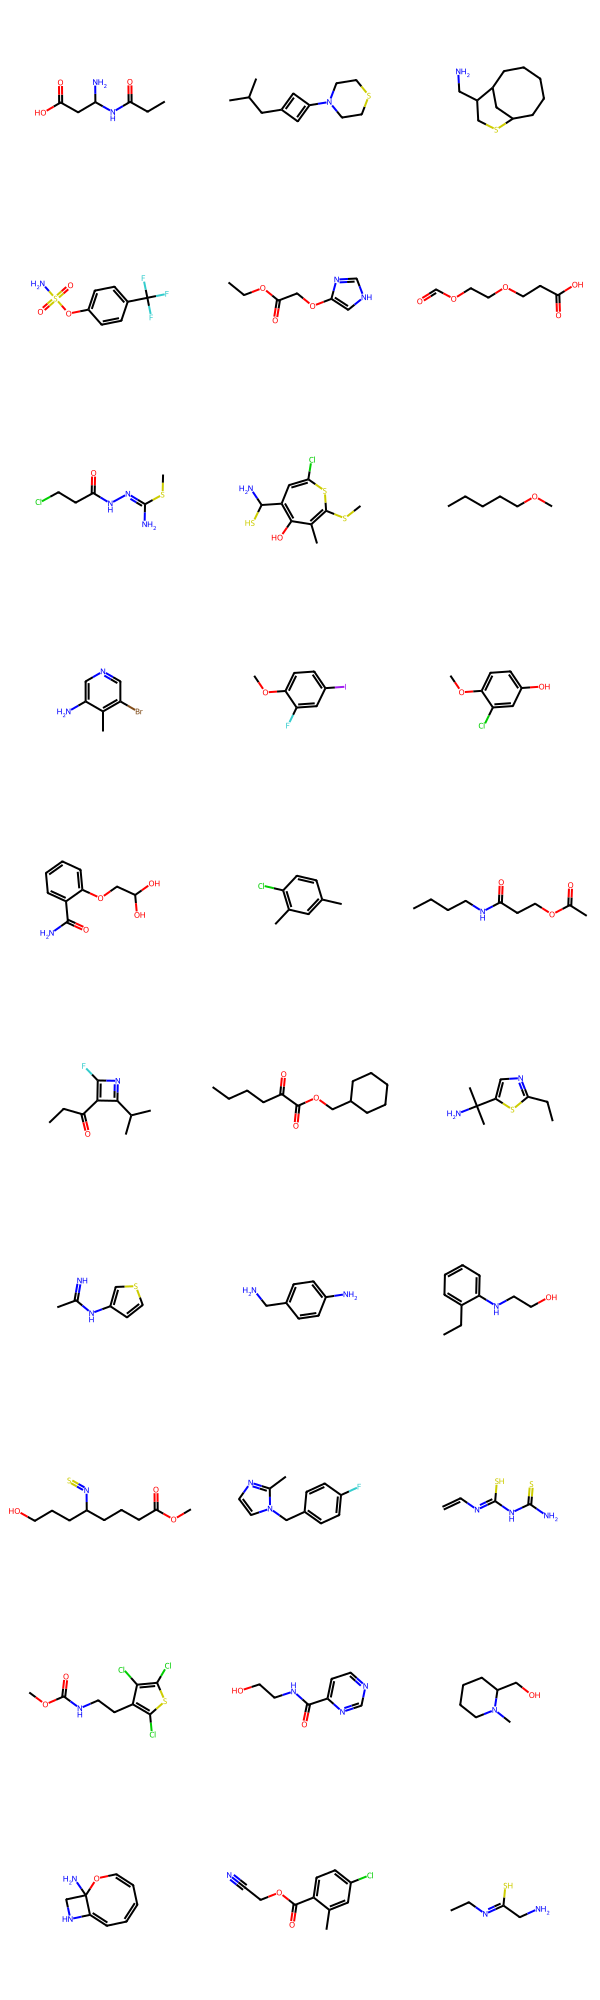

In [ ]:
from rdkit.Chem import MolFromSmiles
from rdkit.RDLogger import DisableLog
from rdkit.Chem.Draw import MolsToGridImage
DisableLog("rdApp.*")

valid_molecules = []
for smiles in generated_smiles_list:
    molecule = MolFromSmiles(smiles)
    if molecule is not None:
        valid_molecules.append(molecule)

MolsToGridImage(valid_molecules[:30])